## Imports libraries

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import pearsonr, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import logging
import plotly.io as pio
import nbformat

In [8]:
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')

In [9]:
# Load dataset
logging.info("Loading dataset")
df = pd.read_csv("Viral_Social_Media_Trends.csv")
logging.info(f"Dataset Shape: {df.shape}")

2025-03-11 09:25:09,914 - Loading dataset
2025-03-11 09:25:09,947 - Dataset Shape: (5000, 10)


In [10]:
# Data Quality Check
logging.info("Checking for missing values and data types")
print("Missing Values:\n", df.isnull().sum())
df.dropna(inplace=True)
for col in ['Platform', 'Hashtag', 'Content_Type', 'Region', 'Engagement_Level']:
    df[col] = df[col].astype('category')

2025-03-11 09:26:10,677 - Checking for missing values and data types


Missing Values:
 Post_ID             0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64


In [11]:
# Basic Stats
logging.info("Basic Statistics:\n%s", df.describe())

2025-03-11 09:28:33,345 - Basic Statistics:
              Views          Likes        Shares      Comments
count  5.000000e+03    5000.000000   5000.000000   5000.000000
mean   2.494066e+06  251475.029800  50519.562000  24888.393800
std    1.459490e+06  144349.583384  29066.362671  14284.504319
min    1.266000e+03     490.000000     52.000000     18.000000
25%    1.186207e+06  126892.250000  25029.000000  12305.250000
50%    2.497373e+06  249443.000000  50839.500000  25004.000000
75%    3.759781e+06  373970.750000  75774.250000  37072.750000
max    4.999430e+06  499922.000000  99978.000000  49993.000000


In [12]:
# Feature Engineering
logging.info("Performing feature engineering")
scaler = StandardScaler()
numeric_cols = ['Views', 'Likes', 'Shares', 'Comments']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df['Engagement_Score'] = df[numeric_cols].mean(axis=1)
df['Log_Views'] = np.log1p(df['Views'].clip(lower=0))
df['Hashtag_Length'] = df['Hashtag'].str.len()

2025-03-11 09:31:27,281 - Performing feature engineering


In [13]:
# Statistical Analysis
def corr_with_significance(x, y, label):
    corr, p_val = pearsonr(x, y)
    logging.info(f"{label} Correlation: {corr:.3f}, p-value: {p_val:.4f}")
    return corr, p_val

corr_with_significance(df['Views'], df['Likes'], "Views vs Likes")
corr_with_significance(df['Shares'], df['Comments'], "Shares vs Comments")

2025-03-11 09:36:09,327 - Views vs Likes Correlation: -0.003, p-value: 0.8223
2025-03-11 09:36:09,329 - Shares vs Comments Correlation: -0.000, p-value: 0.9926


(np.float64(-0.00013162999599924258), np.float64(0.9925755366719404))

In [14]:
# ANOVA for Views by Platform
platforms = df['Platform'].unique()
views_by_platform = [df[df['Platform'] == p]['Views'] for p in platforms]
f_stat, p_val = f_oneway(*views_by_platform)
logging.info(f"ANOVA Views by Platform: F={f_stat:.2f}, p={p_val:.4f}")

2025-03-11 09:39:24,315 - ANOVA Views by Platform: F=2.20, p=0.0857


In [21]:
# Visualization 1: Parallel Coordinates
logging.info("Generating Parallel Coordinates Plot")
fig = px.parallel_coordinates(df, 
                              dimensions=numeric_cols, 
                              color='Engagement_Score', 
                              labels={col: f"{col} (std)" for col in numeric_cols},
                              color_continuous_scale=px.colors.sequential.Viridis,
                              title="Parallel Coordinates of Engagement Metrics")
fig.update_layout(width=800, height=600, title_x=0.5)
fig.write_html("parallel_coordinates.html")  # Save to HTML
# Comment out fig.show() to avoid the error
# fig.show()
print("Parallel Coordinates plot saved as 'parallel_coordinates.html'. Open it in a browser to view.")

2025-03-11 09:52:33,343 - Generating Parallel Coordinates Plot


Parallel Coordinates plot saved as 'parallel_coordinates.html'. Open it in a browser to view.


2025-03-11 09:55:03,490 - Generating Faceted Violin Plot
/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_6688/3230833041.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Figure size 1400x800 with 0 Axes>

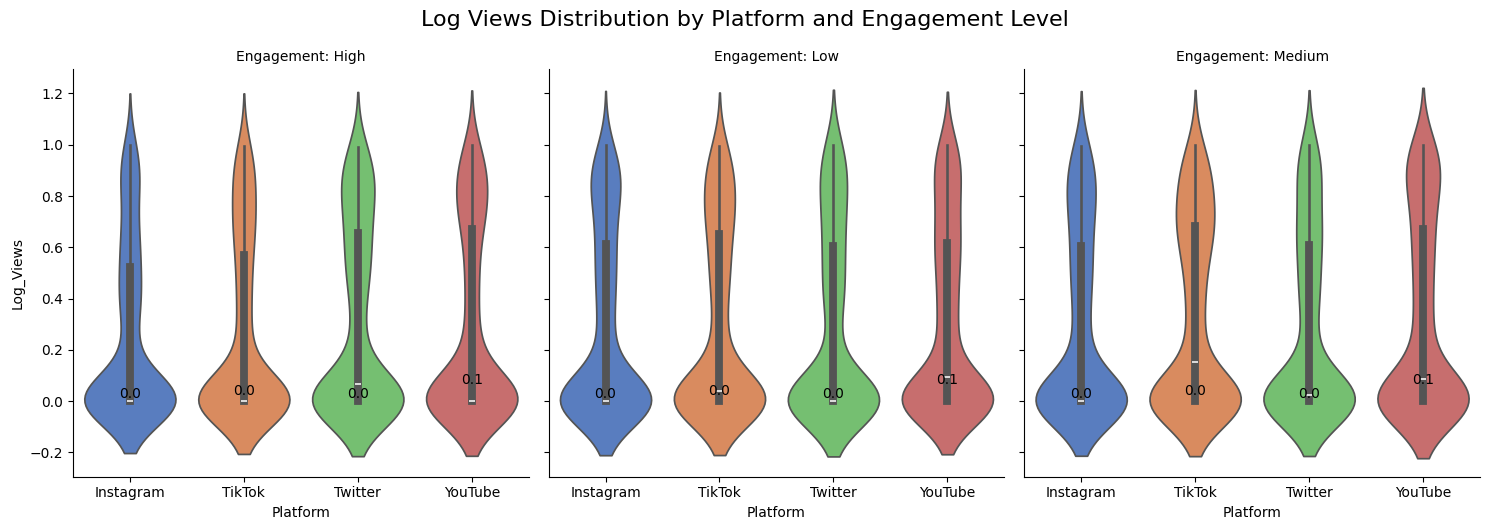

In [22]:
# Visualization 2: Faceted Violin Plot
logging.info("Generating Faceted Violin Plot")
plt.figure(figsize=(14, 8))
g = sns.catplot(data=df, x='Platform', y='Log_Views', col='Engagement_Level', kind='violin', palette='muted', height=5, aspect=1)
g.set_titles("Engagement: {col_name}")
for ax in g.axes.flat:
    for i, platform in enumerate(df['Platform'].cat.categories):
        median = df[df['Platform'] == platform]['Log_Views'].median()
        ax.text(i, median, f'{median:.1f}', ha='center', va='bottom', fontsize=10, color='black')
plt.suptitle("Log Views Distribution by Platform and Engagement Level", y=1.05, fontsize=16)
plt.savefig("faceted_violin.png", dpi=300)
plt.show()